
РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ О НОРМАЛЬНОСТИ (α = 0.05)
Распределение         n       μ̂       σ̂    χ²_набл    χ²_крит    Результат
-------------------------------------------------------------------------------------
Нормальное          100   0.1094   0.9950     2.4471    11.0705  Принимается
Равномерное          20  -0.5550   0.8494     2.4493     5.9915  Принимается
Лапласа              20   0.1729   1.2721     4.4287     5.9915  Принимается

Нормальное (n=100)
------------------------------------------------------------------------------------------
Интервал                          ni       pi     n*pi      ni-n*pi (ni-n*pi)^2/(n*pi)
------------------------------------------------------------------------------------------
(-∞, -1.8470]                      4   0.0246     2.46         1.54             0.9588
(-1.8470, -1.2073]                 5   0.0682     6.82        -1.82             0.4872
(-1.2073, -0.5675]                15   0.1553    15.53        -0.53             0.0179


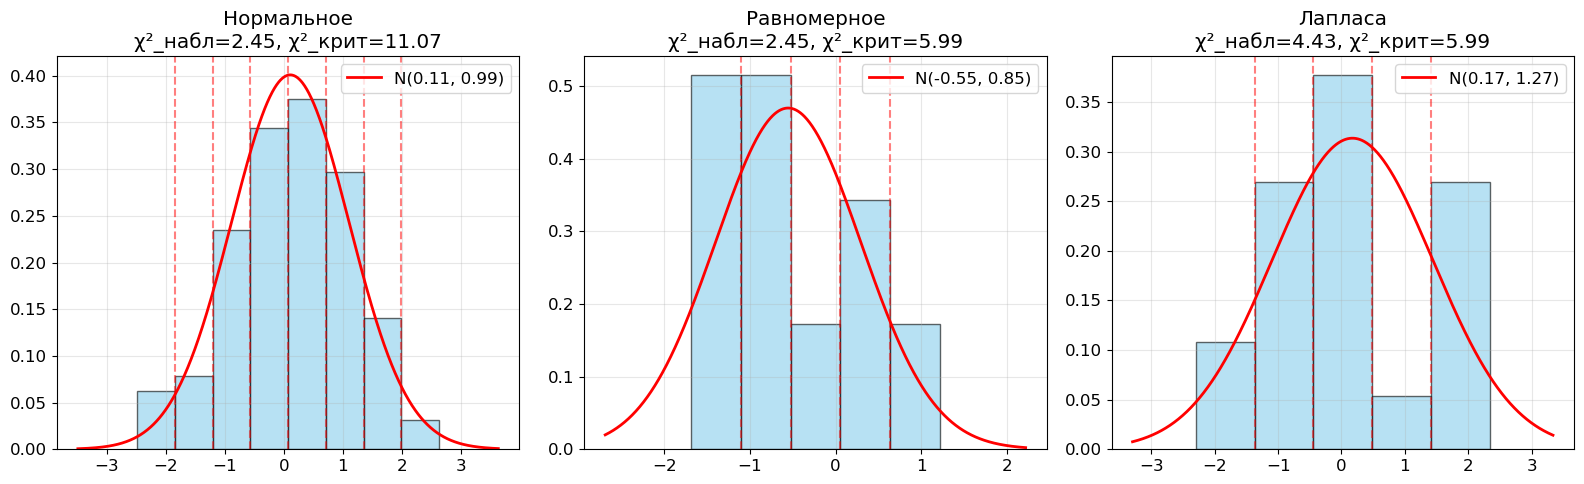

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(6)

def chi2_test(sample, alpha=0.05):
    n = len(sample)
    mu_hat = np.mean(sample)
    sigma_hat = np.std(sample, ddof=0)
    
    k = int(np.round(1 + 3.322 * np.log10(n)))
    if k < 4:
        k = 4
    
    observed, bin_edges = np.histogram(sample, bins=k)
    
    bin_edges_cdf = bin_edges.copy()
    bin_edges_cdf[0] = -np.inf
    bin_edges_cdf[-1] = np.inf
    
    p = np.zeros(k)
    for i in range(k):
        p[i] = stats.norm.cdf(bin_edges_cdf[i+1], mu_hat, sigma_hat) - \
               stats.norm.cdf(bin_edges_cdf[i], mu_hat, sigma_hat)
    
    expected = n * p
    chi2 = np.sum((observed - expected)**2 / expected)
    df = k - 3
    crit = stats.chi2.ppf(1 - alpha, df) if df > 0 else 0
    accept = chi2 < crit if df > 0 else False
    
    return mu_hat, sigma_hat, chi2, crit, df, accept, observed, expected, p, bin_edges

def print_table(title, n, mu, sigma, chi2, crit, accept):
    print(f"{title:<18} {n:>4} {mu:>8.4f} {sigma:>8.4f} {chi2:>10.4f} {crit:>10.4f} {'Принимается' if accept else 'Отвергается':>12}")

def print_details(sample, bin_edges, observed, expected, p, name):
    n = len(sample)
    print(f"\n{name} (n={n})")
    print("-" * 90)
    print(f"{'Интервал':<30} {'ni':>5} {'pi':>8} {'n*pi':>8} {'ni-n*pi':>12} {'(ni-n*pi)^2/(n*pi)':>18}")
    print("-" * 90)
    
    chi2_sum = 0
    for i in range(len(observed)):
        if i == 0:
            interval = f"(-∞, {bin_edges[1]:.4f}]"
        elif i == len(observed) - 1:
            interval = f"({bin_edges[i]:.4f}, +∞)"
        else:
            interval = f"({bin_edges[i]:.4f}, {bin_edges[i+1]:.4f}]"
        
        diff = observed[i] - expected[i]
        term = diff**2 / expected[i]
        chi2_sum += term
        print(f"{interval:<30} {observed[i]:>5} {p[i]:>8.4f} {expected[i]:>8.2f} {diff:>12.2f} {term:>18.4f}")
    
    print("-" * 90)
    print(f"{'СУММА':<30} {np.sum(observed):>5} {1.0:>8.4f} {np.sum(expected):>8.2f} {0.0:>12.2f} {chi2_sum:>18.4f}")

def plot_test(ax, sample, name):
    mu, sigma, chi2, crit, df, accept, obs, exp, p, bins = chi2_test(sample)
    
    ax.hist(sample, bins=bins, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    
    x_grid = np.linspace(min(sample)-1, max(sample)+1, 1000)
    ax.plot(x_grid, stats.norm.pdf(x_grid, mu, sigma), 'r-', lw=2, label=f'N({mu:.2f}, {sigma:.2f})')
    
    for b in bins[1:-1]:
        ax.axvline(b, color='red', linestyle='--', alpha=0.5)
    
    ax.set_title(f"{name}\nχ²_набл={chi2:.2f}, χ²_крит={crit:.2f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

samples = [
    ("Нормальное", np.random.normal(0, 1, 100)),
    ("Равномерное", np.random.uniform(-np.sqrt(3), np.sqrt(3), 20)),
    ("Лапласа", np.random.laplace(0, 1/np.sqrt(2), 20))
]

print("\n" + "="*85)
print("РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ О НОРМАЛЬНОСТИ (α = 0.05)")
print("="*85)
print(f"{'Распределение':<18} {'n':>4} {'μ̂':>8} {'σ̂':>8} {'χ²_набл':>10} {'χ²_крит':>10} {'Результат':>12}")
print("-"*85)

details = []
for name, sample in samples:
    mu, sigma, chi2, crit, df, accept, obs, exp, p, bins = chi2_test(sample)
    print_table(name, len(sample), mu, sigma, chi2, crit, accept)
    details.append((name, sample, bins, obs, exp, p))

for name, sample, bins, obs, exp, p in details:
    print_details(sample, bins, obs, exp, p, name)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (name, sample) in enumerate(samples):
    plot_test(axes[i], sample, name)

plt.tight_layout()
plt.show()